In [ ]:
import pandas as pd
import numpy as np

apps_with_duplicates = pd.read_csv("/Users/betulyilmaz/Downloads/googleplaystore.csv")
apps = apps_with_duplicates.drop_duplicates()

print('Total number of apps in the dataset = ', len(apps))
n = 5
apps.sample(n)

Total number of apps in the dataset =  10358


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
7616,Angelo Rules - Crazy day,GAME,3.9,108336,62M,"1,000,000+",Free,0,Everyone,Adventure,"June 27, 2016",4.0.01,4.4 and up
9714,EP Music,FAMILY,NaN,0,11M,10+,Free,0,Everyone,Entertainment,"July 26, 2017",1.0,4.1 and up
8977,DW - Breaking World News,NEWS_AND_MAGAZINES,4.4,17671,17M,"1,000,000+",Free,0,Everyone 10+,News & Magazines,"August 6, 2018",2.3.10,4.2 and up
3522,Microsoft Word,PRODUCTIVITY,4.5,2084125,Varies with device,"500,000,000+",Free,0,Everyone,Productivity,"July 11, 2018",16.0.10325.20043,4.4 and up
8742,DQSalmaan - A fan made App,FAMILY,4.9,707,6.0M,"10,000+",Free,0,Everyone,Entertainment,"February 4, 2018",1.5,4.1 and up


In [ ]:

# Data Preparation and Cleaning

chars_to_remove = ["+", ",", "$", "M"]
cols_to_clean = ["Installs", "Price", "Size"]

for col in cols_to_clean:
    for char in chars_to_remove:
        apps[col] = apps[col].apply(lambda x: x.replace(char, ""))

apps["Installs"] = apps["Installs"].replace({'Free': None})
apps["Installs"] = apps["Installs"].astype(float)

apps["Size"] = apps["Size"].replace({'Varies with device': None})
apps['Size'] = apps['Size'].apply(lambda x: float(str(x).replace('k', '')) / 1000 if 'k' in str(x) else x)
apps["Size"] = apps["Size"].astype(float)

apps["Price"] = apps["Price"].replace({'Everyone': None})
apps["Price"] = apps["Price"].astype(float)

apps["Category"] = apps["Category"].replace({'1.9': None})

print(apps[apps['Rating'] > 5])
apps["Rating"] = apps["Rating"].replace({19.0: None})

print(apps.dtypes)


                                           App Category  Rating Reviews  \
10472  Life Made WI-Fi Touchscreen Photo Frame     None    19.0    3.0M   

         Size  Installs Type  Price Content Rating             Genres  \
10472  1000.0       NaN    0    NaN            NaN  February 11, 2018   

      Last Updated Current Ver Android Ver  
10472       1.0.19  4.0 and up         NaN  
App                object
Category           object
Rating             object
Reviews            object
Size              float64
Installs          float64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object


/var/folders/3c/8rn2jljj21n79jbbg9tbtpjh0000gn/T/ipykernel_17194/3187745754.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apps[col] = apps[col].apply(lambda x: x.replace(char, ""))
/var/folders/3c/8rn2jljj21n79jbbg9tbtpjh0000gn/T/ipykernel_17194/3187745754.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apps["Installs"] = apps["Installs"].replace({'Free': None})
/var/folders/3c/8rn2jljj21n79jbbg9tbtpjh0000gn/T/ipykernel_17194/3187745754.py:11: SettingWithCopyWarning: 
A value is trying to be set 

In [ ]:
# Artik su sorulari sorabiliriz:
# Pazarda hangi kategori en yuksek paya sahip?
# Hangi kategoride en az sayida uygulama var?

import plotly
import plotly.graph_objs as go
import plotly.offline as py
py.init_notebook_mode(connected=True)

# 'Category' kolonunda kac unique degisken var?
num_categories = len(apps['Category'].unique())
print('Number of categories = ', num_categories)

# 'Category' kolonundaki degiskenlerin sayisi kac?
num_apps_in_category = apps['Category'].value_counts()

sorted_num_apps_in_category = num_apps_in_category.sort_values(ascending = False)
data = [go.Bar(x = num_apps_in_category.index, # index = category name
               y = num_apps_in_category.values, # value = count
               )]

plotly.offline.iplot(data)


Number of categories =  34


In [ ]:
# Uygulama Puanlarinin Dagilimi

avg_app_rating = apps["Rating"].mean()
print('Average app rating = ', avg_app_rating)

data = [go.Histogram(x = apps['Rating'])]

layout = {'shapes': [{
                        'type':'line',
                        'x0': avg_app_rating,
                        'y0': 0,
                        'x1': avg_app_rating,
                        'y1': 1000,
                        'line': { 'dash': 'dashdot'}
                     }]
          }

plotly.offline.iplot({'data': data, 'layout': layout})

# Histogram grafigi, dusuk puanli bir kac istisna uygulama disinda, uygulamalarin cogunun yuksek puan aldigini gosteren sola carpiktir.



Average app rating =  4.187876743139908


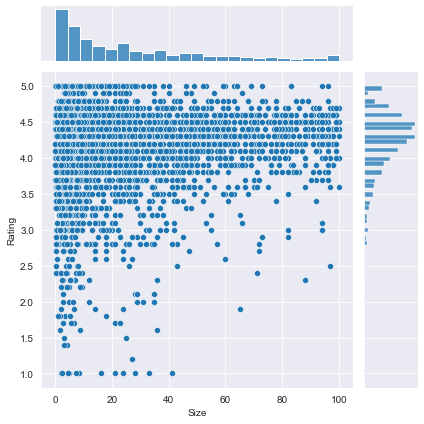

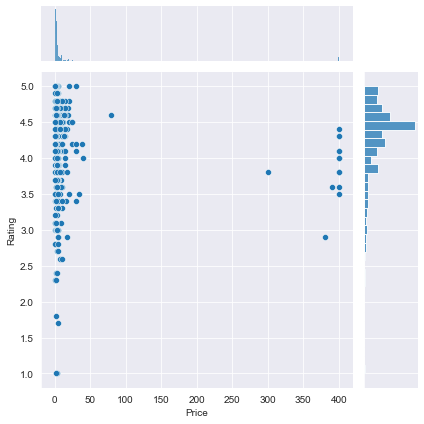

In [8]:
# 'Size' ve 'Price' degiskenlerine bakalim. Uygulamanin boyutu cok buyukse, kullanicinin indirimesi icin zor veya pahali olabilir.

import seaborn as sns
sns.set_style("darkgrid")
import warnings
warnings.filterwarnings("ignore")

apps_with_size_and_rating_present = apps[(~apps['Rating'].isnull()) & (~apps['Size'].isnull())]
large_categories = apps_with_size_and_rating_present.groupby(['Category']).filter(lambda x: len(x) >= 250)


plt1 = sns.jointplot(x = large_categories['Size'], y = large_categories['Rating'])

paid_apps = apps_with_size_and_rating_present[apps_with_size_and_rating_present['Type'] == 'Paid']

plt2 = sns.jointplot(x = paid_apps['Price'], y = paid_apps['Rating'])



,Category,App,Price
4197,FAMILY,most expensive app (H),399.99
4362,LIFESTYLE,💎 I'm rich,399.99
4367,LIFESTYLE,I'm Rich - Trump Edition,400.00
5351,LIFESTYLE,I am rich,399.99
5354,FAMILY,I am Rich Plus,399.99
5355,LIFESTYLE,I am rich VIP,299.99
5356,FINANCE,I Am Rich Premium,399.99
5357,LIFESTYLE,I am extremely Rich,379.99
5358,FINANCE,I am Rich!,399.99
5359,FINANCE,I am rich(premium),399.99


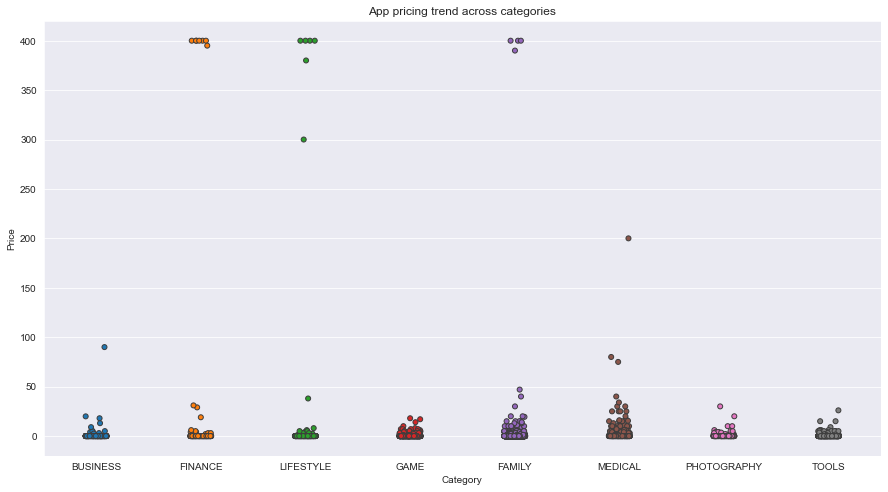

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
fig.set_size_inches(15, 8)

popular_app_cats = apps[apps.Category.isin(['GAME', 'FAMILY', 'PHOTOGRAPHY','MEDICAL', 
                                            'TOOLS', 'FINANCE','LIFESTYLE','BUSINESS'])]

# 'Price' ve 'Category'
ax = sns.stripplot(x = popular_app_cats['Category'],
                    y = popular_app_cats['Price'],
                    jitter = True, linewidth=1)

ax.set_title('App pricing trend across categories')
apps_above_200 = apps[apps['Price'] > 200]
apps_above_200[['Category', 'App', 'Price']]



Text(0.5, 1.0, 'App pricing trend across categories after filtering for junk apps')

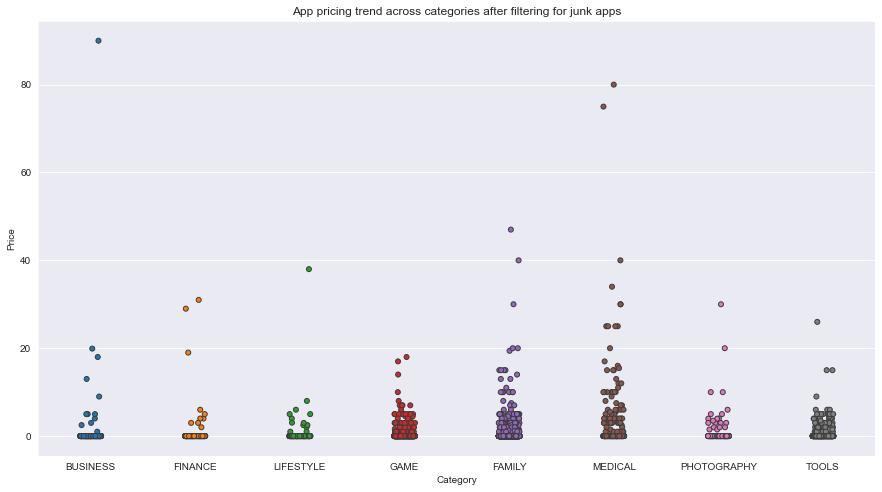

In [10]:
# gercek olmayan "junk" appleri filtreleyelim

apps_under_100 = popular_app_cats[popular_app_cats['Price'] < 100]
fig, ax = plt.subplots()
fig.set_size_inches(15, 8)

ax = sns.stripplot(x = apps_under_100['Category'], y = apps_under_100['Price'], data = apps_under_100, jitter = True, linewidth = 1)
ax.set_title('App pricing trend across categories after filtering for junk apps')



In [11]:
# Ücretli uygulamalar, ücretsiz uygulamalar kadar indiriliyor mu?
trace0 = go.Box(y = apps[apps['Type'] == 'Paid']['Installs'], name = 'Paid')
trace1 = go.Box(y = apps[apps['Type'] == 'Free']['Installs'], name = 'Free')

layout = go.Layout(title = 'Number of downloads of paid apps vs. free apps',
                   yaxis = dict(title = 'Log number of downloads', type = 'log', autorange = True))

data = [trace0, trace1]
plotly.offline.iplot({'data': data, 'layout': layout})

# Ucretli uygulamalar, ucretsiz uygulamalara gore nispeten daha az yukleme sayisina sahip diyebiliriz.

Text(0.5, 1.0, 'Sentiment Polarity Distribution')

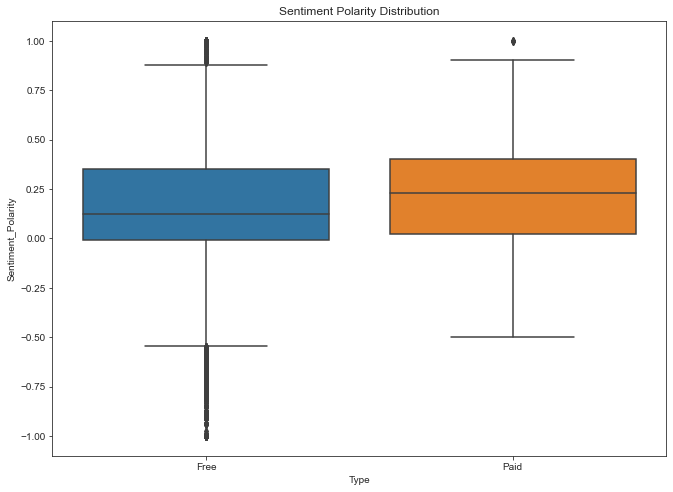

In [18]:
reviews = pd.read_csv('/Users/betulyilmaz/Downloads/archive/googleplaystore_user_reviews.csv')

merged = pd.merge(apps, reviews, on = 'App')
merged = merged.dropna(subset = ['Sentiment', 'Translated_Review'])

sns.set_style('ticks')
fig, ax = plt.subplots()
fig.set_size_inches(11, 8)

ax = sns.boxplot(x = 'Type', y = 'Sentiment_Polarity', data = merged)
ax.set_title('Sentiment Polarity Distribution')






Negatif yorumlari barindiran y eksenindeki aykiri degerlerden goruldugu gibi, ucretsiz uygulamalarin cok sayida sert yorum aldigini gorebiliriz. Ucretli uygulamalar icin hicbir zaman asiri derecede olumsuz yorum gorunmuyor. Bu durum, uygulamanin kalitesiyle ilgili oldugunu, yani ucretli uygulamalarin ucretsiz uygulamalardan daha kaliteli oldugunu soyleyebiliriz.